# LSTM 기반 주가예측모델

## 시계열 데이터 분석 Time Series Data
시계열 데이터란 **시간의 흐름에 따라 관찰하거나 측정한 데이터**를 말한다. 이 데이터는 일반적으로 시간의 순서를 가지며, 특정 시점에서의 값을 나타낸다. 예를 들어, 일일 주식 가격, 시간별 기온, 월별 매출 등이 시계열 데이터의 대표적인 예이다.

**주요 특징**
1. **시간 순서**  
   - 데이터가 시간의 흐름에 따라 정렬되어 있어야 한다. 시간의 순서가 데이터를 분석할 때 중요한 기준이 된다.
2. **시간 종속성**  
   - 이전 시점의 데이터가 이후 시점의 데이터에 영향을 미칠 수 있다.
3. **패턴과 추세**  
   - 주기적인 패턴(계절성)이나 장기적인 변화(추세)를 포함할 수 있다.
4. **불확실성**  
   - 시계열 데이터는 종종 노이즈(잡음)를 포함하며, 예측이 어려울 수 있다.

**활용**
- **금융**: 주식 가격, 환율 변동
- **기상**: 기온, 강수량 예측
- **경제**: GDP, 실업률 변화
- **소비자 행동**: 웹사이트 방문 트래픽, 제품 판매 데이터

**분석 및 모델링 방법**
- **EDA (탐색적 데이터 분석)**  
  - 데이터 시각화, 계절성, 추세 확인
- **통계적 모델링**  
  - ARIMA, SARIMA 등
- **머신러닝**  
  - 시계열 데이터에 특화된 RNN, LSTM, Transformer 등을 활용

시계열 데이터는 과거 데이터를 기반으로 미래를 예측하거나 현재의 상태를 분석하는 데 중요한 역할을 한다.

In [1]:
%pip install finance-datareader

  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)
Using cached plotly-6.9.0-py3-none-any.whl (9.9 MB)

   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------------------------- 1/4 [plotly]
   ---------- ----------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import FinanceDataReader as fdr

In [3]:
# 주가데이터 가져오기
# - 회사별 주식코드(ticker)
samsung_code = '005930'
samsung = fdr.DataReader(samsung_code)
# Open 시가
# High 고가
# Low 저가
# Close 종가
# Volume 거래량
# Change 전날대비 변화량
samsung

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2014-05-22,28819,28960,28520,28520,190800,NaN
2014-05-23,28100,28560,28100,28560,170233,0.001403
2014-05-26,28400,28640,28300,28440,74712,-0.004202
2014-05-27,28340,28460,28059,28140,94968,-0.010549
2014-05-28,28380,28700,28180,28660,184019,0.018479
...,...,...,...,...,...,...
2026-08-06,241500,246000,228000,230500,26101823,-0.063008
2026-08-07,235000,239500,229000,231000,20546010,0.002169
2026-08-10,236000,238500,228500,230000,16327805,-0.004329


In [4]:
apple = fdr.DataReader('AAPL')
apple = fdr.DataReader('AAPL', '2017-01-01', '2017-12-31')
apple.tail()

,Open,High,Low,Close,Volume,Adj Close
2017-12-22,43.669998,43.855000,43.625000,43.752499,65397600,40.874653
2017-12-26,42.700001,42.867500,42.419998,42.642502,132742000,39.837677
2017-12-27,42.525002,42.695000,42.427502,42.650002,85992800,39.844669
2017-12-28,42.750000,42.962502,42.619999,42.770000,65920800,39.956776
2017-12-29,42.630001,42.647499,42.305000,42.307499,103999600,39.524704


## 주식데이터 시각화

In [5]:
naver_code = '035420'
naver = fdr.DataReader(naver_code)
naver.index

DatetimeIndex(['2014-05-22', '2014-05-23', '2014-05-26', '2014-05-27',
               '2014-05-28', '2014-05-29', '2014-05-30', '2014-06-02',
               '2014-06-03', '2014-06-05',
               ...
               '2026-07-30', '2026-07-31', '2026-08-03', '2026-08-04',
               '2026-08-05', '2026-08-06', '2026-08-07', '2026-08-10',
               '2026-08-11', '2026-08-12'],
              dtype='datetime64[us]', name='Date', length=3000, freq=None)

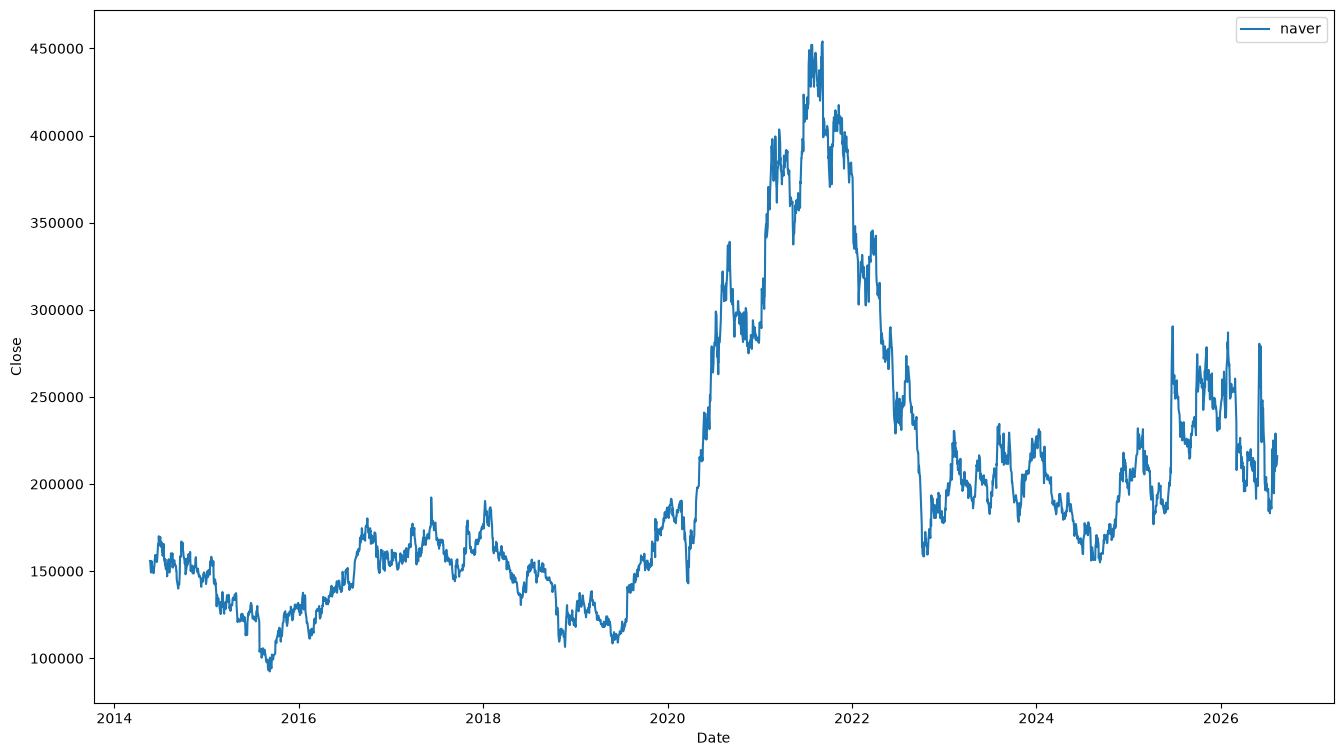

In [6]:
plt.figure(figsize=(16, 9))
plt.plot(naver.index, naver['Close'], label="naver")
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.show()

## 학습데이터 생성

In [7]:
from sklearn.preprocessing import MinMaxScaler

prices = naver['Close'].values

scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices.reshape(-1, 1)).flatten()
prices_scaled

array([0.17531923, 0.17421018, 0.1570378 , ..., 0.32931197, 0.33622628,
       0.34175773], shape=(3000,))

In [8]:
def create_dataset(data, window_size=20):
    X, y = [], []

    for i in range(len(data) - window_size):
        inputs = data[i: i + window_size]
        label = data[i + window_size]
        X.append(inputs)
        y.append(label)

    return np.array(X), np.array(y)

X, y = create_dataset(prices_scaled)
X.shape, y.shape

((2980, 20), (2980,))

In [9]:
df = pd.DataFrame(X)
df['target'] = y
df

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,target
0,0.175319,0.174210,0.157038,0.162578,0.175319,0.171995,0.164240,0.166455,0.162578,0.155932,...,0.178088,0.179750,0.184734,0.179197,0.184181,0.176426,0.173657,0.174763,0.180303,0.201906
1,0.174210,0.157038,0.162578,0.175319,0.171995,0.164240,0.166455,0.162578,0.155932,0.169779,...,0.179750,0.184734,0.179197,0.184181,0.176426,0.173657,0.174763,0.180303,0.201906,0.201353
2,0.157038,0.162578,0.175319,0.171995,0.164240,0.166455,0.162578,0.155932,0.169779,0.178088,...,0.184734,0.179197,0.184181,0.176426,0.173657,0.174763,0.180303,0.201906,0.201353,0.199691
3,0.162578,0.175319,0.171995,0.164240,0.166455,0.162578,0.155932,0.169779,0.178088,0.179750,...,0.179197,0.184181,0.176426,0.173657,0.174763,0.180303,0.201906,0.201353,0.199691,0.214648
4,0.175319,0.171995,0.164240,0.166455,0.162578,0.155932,0.169779,0.178088,0.179750,0.184734,...,0.184181,0.176426,0.173657,0.174763,0.180303,0.201906,0.201353,0.199691,0.214648,0.205231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2975,0.277316,0.254361,0.273444,0.264317,0.251042,0.268743,0.269849,0.258509,0.278146,0.288932,...,0.318249,0.366649,0.325163,0.301655,0.282848,0.319632,0.318249,0.370798,0.377712,0.369415
2976,0.254361,0.273444,0.264317,0.251042,0.268743,0.269849,0.258509,0.278146,0.288932,0.352821,...,0.366649,0.325163,0.301655,0.282848,0.319632,0.318249,0.370798,0.377712,0.369415,0.325163
2977,0.273444,0.264317,0.251042,0.268743,0.269849,0.258509,0.278146,0.288932,0.352821,0.318249,...,0.325163,0.301655,0.282848,0.319632,0.318249,0.370798,0.377712,0.369415,0.325163,0.329312
2978,0.264317,0.251042,0.268743,0.269849,0.258509,0.278146,0.288932,0.352821,0.318249,0.366649,...,0.301655,0.282848,0.319632,0.318249,0.370798,0.377712,0.369415,0.325163,0.329312,0.336226


In [10]:
# 텐서 변환
import torch

X_tensor = torch.tensor(X, dtype=torch.float).unsqueeze(-1)
y_tensor = torch.tensor(y, dtype=torch.float).unsqueeze(-1)
X_tensor.shape, y_tensor.shape

(torch.Size([2980, 20, 1]), torch.Size([2980, 1]))

In [11]:
# 학습/검증 분리
train_size = int(len(X_tensor) * 0.8)
X_train, X_val = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_val = y_tensor[:train_size], y_tensor[train_size:]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

torch.Size([2384, 20, 1]) torch.Size([2384, 1])
torch.Size([596, 20, 1]) torch.Size([596, 1])


## Conv1d 레이어

<img src="https://controlandlearning.wordpress.com/wp-content/uploads/2020/07/figure-1.png" width="500"/>

**1. Conv1d란?**

`nn.Conv1d`는 1차원 시퀀스 데이터를 위한 합성곱 레이어이다.  
예: 시계열 데이터, 텍스트 임베딩 등

**2. 입력/출력 형태**

- 입력 shape: `(batch_size, in_channels, seq_len)`
- 출력 shape: `(batch_size, out_channels, new_seq_len)`

**3. 주요 파라미터**

| 파라미터           | 설명                                        |
| -------------- | ----------------------------------------- |
| `in_channels`  | 입력 채널 수 (예: 임베딩 차원, 또는 이전 conv의 출력 채널 수)  |
| `out_channels` | 출력 채널 수 (필터 개수, convolution 결과 feature 수) |
| `kernel_size`  | 필터 크기 (한 번에 보는 시점의 개수)                    |
| `stride`       | 필터가 이동하는 간격 (기본값=1)                       |
| `padding`      | 입력 시퀀스 앞뒤에 0을 덧붙여서 시퀀스 길이를 조절 (기본값=0)     |


**4.출력길이 계산**

- L: 원래 시퀀스 길이

```
output_length = floor((L + 2 * padding - kernel_size) / stride) + 1
```
위 이미지에서는 패딩이 없으므로 `(5 + 2 * 0 - 2) / 1 + 1 = 4`로 처리

In [12]:
# con1d 구조
import torch
import torch.nn as nn

x = torch.randn(1, 20, 1) # (batch_size, seq_len, input_size)
print('입력:', x.shape)

conv1d = nn.Conv1d(
    in_channels=1,
    out_channels=32, # 필터(커널수)
    kernel_size=5,
    padding=4
)

x = x.permute(0, 2, 1)
print('in 차원변환:', x.shape)
# conv1d 요구사항:  (batch_size, input_size, seq_len)
x = conv1d(x)
print('conv1d출력:', x.shape)
x = x.permute(0, 2, 1)
print('out 차원변환:', x.shape)


입력: torch.Size([1, 20, 1])
in 차원변환: torch.Size([1, 1, 20])
conv1d출력: torch.Size([1, 32, 24])
out 차원변환: torch.Size([1, 24, 32])


## 모델 생성

In [13]:
import torch.nn as nn

class StockLSTM(nn.Module):

    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            conv_filters,
            conv_kernel_size):
        super().__init__()
        self.conv1d = nn.Conv1d(input_size,
                                conv_filters,
                                kernel_size=conv_kernel_size,
                                padding=conv_kernel_size - 1)
        self.lstm = nn.LSTM(conv_filters, hidden_size,
                            num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x = (batch_size, seq_len, input_size)
        x = x.permute(0, 2, 1)
        x = self.conv1d(x) # (batch_size, channels, seq_len)
        x = x.permute(0, 2, 1)
        _, (hidden, _) = self.lstm(x)
        output = self.fc1(hidden[-1])
        output = self.relu(output)
        output = self.fc2(output)
        return output



## 모델 학습

In [14]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = StockLSTM(input_size=1,
                  hidden_size=64,
                  num_layers=2,
                  conv_filters=32,
                  conv_kernel_size=5).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)


# 학습
epochs = 50
batch_size = 32

for epoch in range(epochs):
    model.train()
    # 데이터 순서 섞기
    permutation = torch.randperm(X_train.size()[0])
    train_loss = 0

    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i : i + batch_size]
        X_batch = X_train[indices].to(device)
        y_batch = y_train[indices].to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 검증
    model.eval()
    with torch.no_grad():
        X_val = X_val.to(device)
        y_val = y_val.to(device)
        output = model(X_val)
        loss = criterion(output, y_val)
        val_loss = loss.item()

    print(f'Epoch {epoch + 1}/{epochs}: '
          f'Train Loss {train_loss:.6f}, '
          f'Val Loss {val_loss:.6f}')

Epoch 1/50: Train Loss 3.718176, Val Loss 0.007573
Epoch 2/50: Train Loss 0.089698, Val Loss 0.000675
Epoch 3/50: Train Loss 0.039842, Val Loss 0.001081
Epoch 4/50: Train Loss 0.046092, Val Loss 0.000611
Epoch 5/50: Train Loss 0.028099, Val Loss 0.001301
Epoch 6/50: Train Loss 0.028000, Val Loss 0.000451
Epoch 7/50: Train Loss 0.030536, Val Loss 0.000438
Epoch 8/50: Train Loss 0.025416, Val Loss 0.000458
Epoch 9/50: Train Loss 0.029242, Val Loss 0.000467
Epoch 10/50: Train Loss 0.027932, Val Loss 0.000596
Epoch 11/50: Train Loss 0.023895, Val Loss 0.001252
Epoch 12/50: Train Loss 0.024135, Val Loss 0.000606
Epoch 13/50: Train Loss 0.024623, Val Loss 0.000419
Epoch 14/50: Train Loss 0.022104, Val Loss 0.000373
Epoch 15/50: Train Loss 0.020335, Val Loss 0.000365
Epoch 16/50: Train Loss 0.020833, Val Loss 0.000391
Epoch 17/50: Train Loss 0.018181, Val Loss 0.000353
Epoch 18/50: Train Loss 0.021414, Val Loss 0.000388
Epoch 19/50: Train Loss 0.017813, Val Loss 0.000364
Epoch 20/50: Train Lo

## 모델 예측/시각화

In [15]:
model.eval()
with torch.no_grad():
    X_val = X_val.to(device)
    output = model(X_val)
    pred = output.detach().cpu().numpy()

# 스케일복원
pred_inverse = scaler.inverse_transform(pred)
y_val = y_val.detach().cpu().numpy()
y_val_inverse = scaler.inverse_transform(y_val)

pred_inverse[-1], y_val_inverse[-1]

(array([216086.], dtype=float32), array([215999.98], dtype=float32))

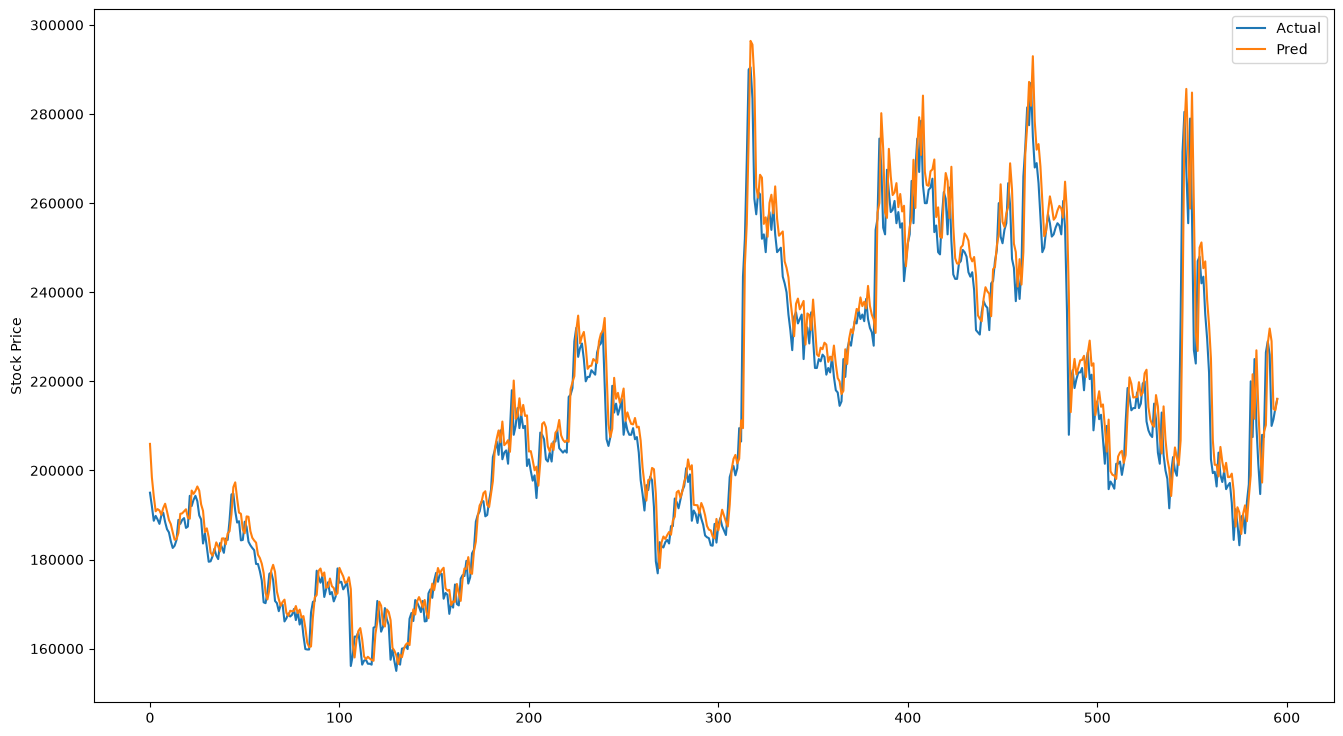

In [16]:
plt.figure(figsize=(16, 9))
plt.plot(y_val_inverse, label='Actual')
plt.plot(pred_inverse, label='Pred')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

## 모델 예측

In [17]:
# 모델 예측
def predict_next_stock_price(data, model, scaler, device):
    # 스케일링
    data_scaled = scaler.transform(data.reshape(-1, 1))
    # 텐서변환
    data_tensor = torch.tensor(data_scaled, dtype=torch.float).unsqueeze(0)
    data_tensor = data_tensor.to(device)
    print(data_tensor.shape)
    # 모델예측
    model.eval()
    with torch.no_grad():
        output = model(data_tensor)
        pred = output.detach().cpu().numpy()

    # 역스케일링
    pred_inverse = scaler.inverse_transform(pred)
    return pred_inverse[-1]

data = naver['Close'].values[-20:] # ndarray
pred_price = predict_next_stock_price(data, model, scaler, device)
pred_price

torch.Size([1, 20, 1])


array([218349.52], dtype=float32)